In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import os 
import glob

In [2]:
adata = sc.read_h5ad('/data1st1/junyi/correctdata/GSE133549/all.h5ad')

In [6]:
adata.obs

,source_file,sample_id
10X2x5K_64220_AAACCTGAGACGCACA,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGAGCCACCTG,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGAGTGCGTGA,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGCACTGTGTA,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGCAGACTCGC,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
...,...,...
1CB_S1_TTTGTGTCCTATAGAG,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz
1CB_S1_TTTGTGTCCTTCAGGT,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz
1CB_S1_TTTGTGTCGCTTCAAT,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz
1CB_S1_TTTGTGTCTCCAGTCC,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz


In [ ]:
adata.obs 

AnnData object with n_obs × n_vars = 139617 × 47768
    obs: 'source_file', 'sample_id', 'platform'
    layers: None (.X)

In [43]:
adata.obs['sample_id'].value_counts()

sample_id
GSE133536_10X8x10Kcell25Kreads_human_exp_mat.tsv.gz    80000
GSE133535_10X2x5Kcell250Kreads_human_exp_mat.tsv.gz    10000
GSE133538_C1HTsmall_human_exp_mat.tsv.gz                6400
GSE133540_Dropseq_human_exp_mat.tsv.gz                  6000
GSE133546_SingleNuclei_human_exp_mat.tsv.gz             6000
GSE133537_C1HTmedium_human_exp_mat.tsv.gz               5600
GSE133547_ddSEQ_human_exp_mat.tsv.gz                    4000
GSE133541_ICELL8_human_exp_mat.tsv.gz                   3928
GSE133544_SCRBseq_human_exp_mat.tsv.gz                  3455
GSE133543_QUARTZseq_human_exp_mat.tsv.gz                3070
GSE133545_SMARTseq2_human_exp_mat.tsv.gz                2992
GSE133548_inDrop_human_exp_mat.tsv.gz                   2988
GSE133539_CELseq2_human_exp_mat.tsv.gz                  2880
GSE133542_MARSseq_human_exp_mat.tsv.gz                  2304
Name: count, dtype: int64

In [4]:
# ==== 把 CellBench_metadata 里的全部 metadata 导入 pandas（GSE118767 的 ground truth 标签）====
meta_dir = "/data1st1/junyi/correctdata/GSE118767/CellBench_metadata/"

# 1) 读入全部 14 个 metadata 文件，行名 = 细胞/孔位，加 dataset 列标注来源
meta_files = sorted(glob.glob(os.path.join(meta_dir, "*.metadata.csv.gz")))
print(f"找到 {len(meta_files)} 个 metadata 文件")

frames = []
for fp in meta_files:
    dataset = os.path.basename(fp).replace(".metadata.csv.gz", "")
    df = pd.read_csv(fp, index_col=0)
    df.index.name = "cell"
    df["dataset"] = dataset
    frames.append(df)
meta_all = pd.concat(frames)
print("合并后形状:", meta_all.shape)

# 2) 修正 CellBench 的数据 bug：5cl 板的 p2/p3 行名被误标成 p1_ 前缀 -> 统一剥掉 p1_
mask5cl = meta_all["dataset"].str.startswith("sc_celseq2_5cl")
meta_all.index = [i[3:] if (m and i.startswith("p1_")) else i
                  for m, i in zip(mask5cl, meta_all.index)]

# 3) 只保留标签列（去掉 unaligned/mapped_* 等纯 QC 统计列），方便使用
LABEL_COLS = ["H1975", "H2228", "HCC827", "traj", "poor_quality",          # cellmix: 每孔各细胞系细胞数
              "H2228_prop", "H1975_prop", "HCC827_prop", "mRNA_amount", "mix",  # RNAmix: RNA 混合比例
              "cell_line", "cell_line_demuxlet", "demuxlet_cls"]           # 单细胞: 每细胞细胞系身份
labels = meta_all[LABEL_COLS + ["dataset"]].copy()
print()
print("=== 每个数据集的标签覆盖（非空行数）===")
print(labels.groupby("dataset")[LABEL_COLS].apply(lambda s: s.notna().sum()).to_string())
print()
print("=== 抽查 ===")
labels[labels["dataset"] == "cellmix1"].head(3)

找到 14 个 metadata 文件
合并后形状: (7992, 47)

=== 每个数据集的标签覆盖（非空行数）===
                   H1975  H2228  HCC827  traj  poor_quality  H2228_prop  H1975_prop  HCC827_prop  mRNA_amount  mix  cell_line  cell_line_demuxlet  demuxlet_cls
dataset                                                                                                                                                        
RNAmix_celseq2         0      0       0     0             0         340         340          340          340  340          0                   0             0
RNAmix_sortseq         0      0       0     0             0         296         296          296          296  296          0                   0             0
cellmix1             266    266     266   266           266           0           0            0            0    0          0                   0             0
cellmix2             268    268     268   268           268           0           0            0            0    0          0            

,H1975,H2228,HCC827,traj,poor_quality,H2228_prop,H1975_prop,HCC827_prop,mRNA_amount,mix,cell_line,cell_line_demuxlet,demuxlet_cls,dataset
L19,7.0,0.0,2.0,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cellmix1
A10,0.0,0.0,9.0,YES,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cellmix1
A11,0.0,0.0,9.0,YES,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cellmix1


In [7]:
labels.drop_duplicates(subset=["dataset"])

,H1975,H2228,HCC827,traj,poor_quality,H2228_prop,H1975_prop,HCC827_prop,mRNA_amount,mix,cell_line,cell_line_demuxlet,demuxlet_cls,dataset
L19,NaN,NaN,NaN,NaN,NaN,0.68,0.16,0.16,30.0,6.0,NaN,NaN,NaN,RNAmix_celseq2
L19,NaN,NaN,NaN,NaN,NaN,0.68,0.16,0.16,30.0,6.0,NaN,NaN,NaN,RNAmix_sortseq
L19,7.0,0.0,2.0,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cellmix1
L19,7.0,0.0,2.0,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cellmix2
L19,7.0,0.0,2.0,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cellmix3
L19,7.0,0.0,2.0,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cellmix4
O1,10.0,10.0,70.0,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cellmix5
CELL_000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HCC827,HCC827,SNG,sc_10x
Lib90_00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HCC827,HCC827,SNG,sc_10x_5cl
A1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,H1975,H1975,SNG,sc_celseq2


In [79]:
adata

AnnData object with n_obs × n_vars = 139617 × 47768
    obs: 'source_file', 'sample_id', 'platform'
    layers: None (.X)

In [45]:
adata_subset = adata[adata.obs["sample_id"].isin(["GSE133536_10X8x10Kcell25Kreads_human_exp_mat.tsv.gz", 
                                                  "GSE133535_10X2x5Kcell250Kreads_human_exp_mat.tsv.gz", 
                                                  "GSE133540_Dropseq_human_exp_mat.tsv.gz", 
                                                  "GSE133546_SingleNuclei_human_exp_mat.tsv.gz"])].copy()

In [ ]:
adata_subset.obs[]

In [72]:
adata_subset.obs['platform'] = adata_subset.obs['sample_id'].str.split('_', expand=True)[1]

In [76]:
adata_subset.layers['counts'] = adata_subset.X.copy()

In [80]:
sc.pp.filter_cells(adata_subset, min_genes=100)
sc.pp.filter_genes(adata_subset, min_cells=3)


In [82]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_subset)
# Logarithmize the data
sc.pp.log1p(adata_subset)


In [84]:
sc.pp.highly_variable_genes(adata_subset, n_top_genes=2000, batch_key="platform")


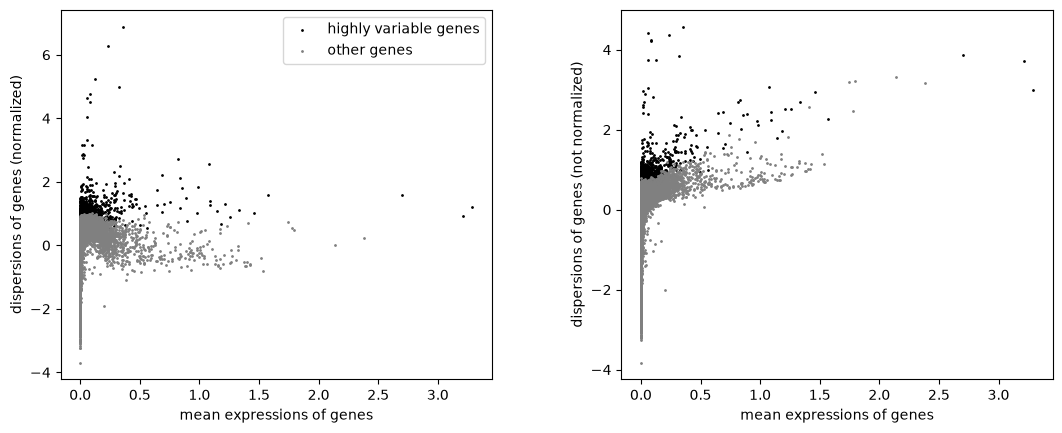

In [86]:
sc.pl.highly_variable_genes(adata_subset)


In [88]:
sc.tl.pca(adata_subset)


/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


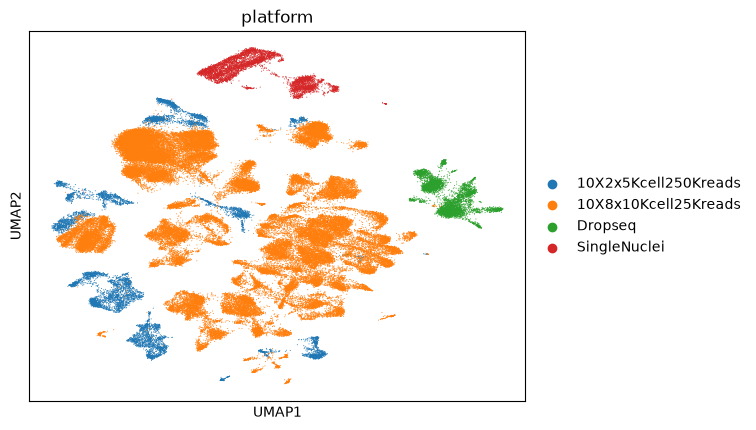

In [89]:
sc.pp.neighbors(adata_subset)
sc.tl.umap(adata_subset)
sc.pl.umap(
    adata_subset,
    color="platform",
    # Setting a smaller point size to get prevent overlap
    size=2,
)


In [90]:
adata_subset.obs['company']=adata_subset.obs['platform']
adata_subset.write_h5ad('/data1st1/junyi/correctdata/GSE133549/adata_subset.h5ad')